# Inference
Step 1 - Load everything needed for inference

weights=None — this time we build the architecture without downloading ImageNet weights, since we're about to load our own trained weights instead — no point loading two sets of weights

Same classifier modification as training (must match exactly, or the saved weights won't load correctly)

map_location=device — ensures the saved weights load correctly onto whichever device (GPU/CPU) is available, avoiding a common error when loading GPU-trained weights on a machine without GPU

Same transform pipeline as training — critical: inference must preprocess images identically to how training data was preprocessed, or the model sees different-looking input than it learned on

Config - loads project paths once. Works from any machine/clone location; only `config.py` needs to exist at the repo root.

In [12]:
pip install ipywidgets

Note: you may need to restart the kernel to use updated packages.


In [36]:
# Cell 1 — Setup: load model + preprocessing
from config import BASE_DIR, DATASETS_DIR, SAVED_MODELS_DIR, OUTPUTS_DIR
import torch
import torch.nn as nn
from torchvision import models, transforms
import cv2
from PIL import Image
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.efficientnet_b0(weights=None)
num_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(num_features, 2)
model.load_state_dict(torch.load(str(SAVED_MODELS_DIR / "efficientnet_best.pth"), map_location=device))
model = model.to(device)
model.eval()

class_names = ['fake', 'real']
IMG_SIZE = 224
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
print("Model loaded, ready for inference.")

Model loaded, ready for inference.


Step 2- Prediction function (with face-crop preprocessing)

Applies the exact same face-crop logic used during preprocessing — consistency between training and inference preprocessing is essential, mismatches here are a very common source of poor real-world performance

unsqueeze(0) — adds a "batch dimension" of size 1, since the model expects batches of images, not a single raw image
Returns a clean dictionary with prediction, confidence, and both class probabilities — exactly what we'll display in the Gradio UI next

In [37]:
# Cell 2 — Grad-CAM (moved BEFORE predict_image, since predict_image depends on it)
import torch.nn.functional as F
import numpy as np

class GradCAM:
    def __init__(self, model, target_layer=None):
        self.model = model
        self.target_layer = target_layer or model.features[-1]
        self.activations = None
        self.gradients = None
        self.target_layer.register_forward_hook(self._save_activation)
        self.target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, input, output):
        self.activations = output.detach()

    def _save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, input_tensor, class_idx):
        input_tensor = input_tensor.clone().requires_grad_(True)
        logits = self.model(input_tensor)
        self.model.zero_grad()
        logits[0, class_idx].backward()
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = F.relu((weights * self.activations).sum(dim=1, keepdim=True))
        cam = F.interpolate(cam, size=(IMG_SIZE, IMG_SIZE), mode="bilinear", align_corners=False)
        cam = cam.squeeze().detach().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam

REGION_GRID = [
    ["forehead / hairline", "forehead / hairline", "forehead / hairline"],
    ["left eye / temple", "eyes / nose bridge", "right eye / temple"],
    ["jaw / cheek (left)", "mouth / chin", "jaw / cheek (right)"],
]

def heatmap_to_regions(heatmap, top_k=2):
    h, w = heatmap.shape
    ch, cw = h // 3, w // 3
    scores = {}
    for i in range(3):
        for j in range(3):
            cell = heatmap[i*ch:(i+1)*ch, j*cw:(j+1)*cw]
            label = REGION_GRID[i][j]
            scores[label] = scores.get(label, 0.0) + float(cell.mean())
    total = sum(scores.values()) + 1e-8
    ranked = sorted(scores.items(), key=lambda x: x[1], reverse=True)
    return [(label, s / total) for label, s in ranked[:top_k]]

gradcam = GradCAM(model)
print("Grad-CAM ready.")

Grad-CAM ready.


Error Level Analysis (ELA)

In [38]:
# Cell 3 — Error Level Analysis (ELA): second, independent forensic visual signal
from PIL import ImageChops, ImageEnhance
import io

def compute_ela(image_path, quality=90, scale=15):
    """
    Re-saves the image at a known JPEG quality and measures the pixel-level
    difference from the original. Regions with different compression
    history (e.g. spliced/edited areas) show up brighter — a classical
    forensic signal, independent of and complementary to Grad-CAM.
    """
    original = Image.open(image_path).convert('RGB')

    buffer = io.BytesIO()
    original.save(buffer, 'JPEG', quality=quality)
    buffer.seek(0)
    resaved = Image.open(buffer)

    diff = ImageChops.difference(original, resaved)
    extrema = diff.getextrema()
    max_diff = max([ex[1] for ex in extrema]) or 1
    scale_factor = min(255.0 / max_diff, scale)
    return ImageEnhance.Brightness(diff).enhance(scale_factor)

print("ELA function ready.")

ELA function ready.


Prediction Function

In [39]:
# Cell 4 — Prediction function (Grad-CAM regions + ELA image, both included)
def predict_image(image_path):
    img = cv2.imread(image_path)
    if img is None:
        return {"error": "Could not read image"}

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(60, 60))

    if len(faces) > 0:
        faces = sorted(faces, key=lambda f: f[2] * f[3], reverse=True)
        x, y, w, h = faces[0]
        face_crop = img[y:y+h, x:x+w]
    else:
        face_crop = img

    face_rgb = cv2.cvtColor(face_crop, cv2.COLOR_BGR2RGB)
    pil_img = Image.fromarray(face_rgb)
    input_tensor = transform(pil_img).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(input_tensor)
        probs = torch.softmax(output, dim=1)[0]
        pred_idx = torch.argmax(probs).item()
        confidence = probs[pred_idx].item()

    heatmap = gradcam.generate(input_tensor, pred_idx)
    top_regions = heatmap_to_regions(heatmap)
    ela_image = compute_ela(image_path)

    return {
        "prediction": class_names[pred_idx],
        "confidence": round(confidence * 100, 2),
        "fake_probability": round(probs[0].item() * 100, 2),
        "real_probability": round(probs[1].item() * 100, 2),
        "top_regions": top_regions,
        "ela_image": ela_image
    }

Step 3 - Quick test

In [49]:
# Cell 5 — Let the user pick ANY image, instead of a hardcoded test-set path
import ipywidgets as widgets
from IPython.display import display

upload_widget = widgets.FileUpload(
    accept='.jpg,.jpeg,.png,.bmp,.webp',
    multiple=False,
    description='Upload image'
)
display(upload_widget)
print("Upload any image above, then run the next cell.")

FileUpload(value=(), accept='.jpg,.jpeg,.png,.bmp,.webp', description='Upload image')

Upload any image above, then run the next cell.


Step 4 - install the Hugging Face Hub client (if not already active)

token already taken

In [41]:
import huggingface_hub
print(huggingface_hub.__version__)

1.24.0


Step 5 - Set up the client with your token

In [42]:
# Cell 6 — Hugging Face client setup
from huggingface_hub import InferenceClient
from dotenv import load_dotenv

load_dotenv(str(BASE_DIR / ".env"))
HF_TOKEN = os.getenv("HF_TOKEN")

assert HF_TOKEN and len(HF_TOKEN) > 10, "HF_TOKEN missing or invalid — check your .env file."

client = InferenceClient(api_key=HF_TOKEN, provider="auto")
print("Hugging Face client ready.")

Hugging Face client ready.


step 6 - Generate a natural-language explanation

provider="auto" — tells Hugging Face to route your request to whichever backend provider actually hosts the requested model, instead of assuming hf-inference (their own free serverless tier) has it

client.chat.completions.create(...) — this is the newer OpenAI-compatible method name (matches current HF docs); functionally the same as chat_completion, just the current recommended syntax

deepseek-ai/DeepSeek-V3-0324 — a model confirmed (per HF's own current documentation) to be actively served through their provider network

In [43]:
# Cell 7 — Explanation generation, grounded in Grad-CAM regions
def confidence_margin(result):
    return abs(result["fake_probability"] - result["real_probability"]) / 100

def generate_explanation(result):
    margin = confidence_margin(result)
    region_str = ", ".join(f"{name} ({w*100:.0f}% of model attention)" for name, w in result["top_regions"])

    prompt = f"""Detection result: {result['prediction'].upper()}
Confidence: {result['confidence']}%
Fake probability: {result['fake_probability']}%
Real probability: {result['real_probability']}%
Confidence margin between the two classes: {margin*100:.0f} points ({'a decisive call' if margin >= 0.3 else 'a borderline call'})
Grad-CAM shows the model's attention was concentrated on: {region_str}

Write a short, 3-4 sentence explanation for the user about this deepfake
detection result. Reference the specific facial region(s) listed above and
explain in plain terms why attention on that region is meaningful for
detecting manipulation (e.g. eyes/nose bridge often show blending seams,
mouth/chin often show unnatural texture in face-swaps). Use ONLY the facts
given above — do not invent details you weren't given. Be honest this is a
statistical prediction, not certainty."""

    try:
        response = client.chat.completions.create(
            model="deepseek-ai/DeepSeek-V3-0324",
            messages=[{"role": "user", "content": prompt}],
            max_tokens=200
        )
        return response.choices[0].message.content
    except Exception as e:
        print(f"Explanation generation failed ({type(e).__name__}), using fallback.")
        top_region = result["top_regions"][0][0] if result.get("top_regions") else "the face"
        return (f"The model predicted '{result['prediction']}' with {result['confidence']}% confidence, "
                f"with attention concentrated on the {top_region}. This is a statistical estimate, not certainty.")


def predict_with_explanation(image_path):
    result = predict_image(image_path)
    if "error" in result:
        return result
    result["explanation"] = generate_explanation(result)
    return result

combine prediction + explanation into one clean function

In [44]:
print("Token loaded:", HF_TOKEN is not None and len(HF_TOKEN) > 10)

Token loaded: True


Full Test

In [45]:
import ipywidgets
print(ipywidgets.__version__)

8.1.8


Using uploaded image: 00561.jpg

Prediction: real (97.74%)
Top regions: [('eyes / nose bridge', 0.28466159275977065), ('mouth / chin', 0.2696411377904583)]

Explanation:
 This result indicates the video is very likely real, with a 97.74% confidence score. The model focused heavily on the eyes/nose bridge (28%) and mouth/chin (27%), which are common areas where deepfakes show flaws—like blending seams around the eyes or unnatural textures in mouth movements. While the prediction strongly favors authenticity, it’s based on statistical patterns, not absolute certainty. The high confidence margin (95 points) suggests the model found clear, consistent details in these regions that align with unaltered footage.


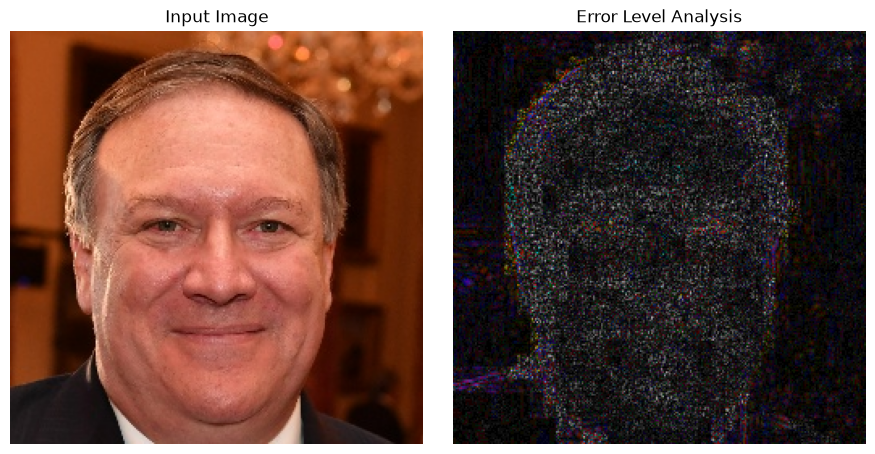

In [50]:
# Cell 8 — Run prediction on the uploaded image (or fall back to a test-set sample)
import matplotlib.pyplot as plt

if len(upload_widget.value) > 0:
    uploaded = upload_widget.value

    # Handle both ipywidgets APIs:
    # - ipywidgets >= 8: value is a tuple/list of dicts with 'name' and 'content'
    # - ipywidgets < 8: value is a dict keyed by filename, each with 'metadata' and 'content'
    if isinstance(uploaded, (tuple, list)):
        uploaded_file = uploaded[0]
        file_name = uploaded_file['name']
        file_content = uploaded_file['content']
    else:
        uploaded_file = list(uploaded.values())[0]
        file_name = uploaded_file['metadata']['name']
        file_content = uploaded_file['content']

    user_image_path = str(OUTPUTS_DIR / file_name)
    with open(user_image_path, 'wb') as f:
        f.write(file_content)
    print(f"Using uploaded image: {file_name}")
else:
    user_image_path = os.path.join(str(DATASETS_DIR / "test" / "real"), os.listdir(str(DATASETS_DIR / "test" / "real"))[0])
    print("No image uploaded — using a sample test-set image instead.")

final_result = predict_with_explanation(user_image_path)
print("\nPrediction:", final_result["prediction"], f"({final_result['confidence']}%)")
print("Top regions:", final_result["top_regions"])
print("\nExplanation:\n", final_result["explanation"])

fig, axes = plt.subplots(1, 2, figsize=(9, 4.5))
axes[0].imshow(Image.open(user_image_path))
axes[0].set_title("Input Image")
axes[0].axis('off')
axes[1].imshow(final_result["ela_image"])
axes[1].set_title("Error Level Analysis")
axes[1].axis('off')
plt.tight_layout()
plt.savefig(str(BASE_DIR / "reports" / "ela_comparison.png"), dpi=150)
plt.show()